In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import pickle
from scipy import sparse
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.pipeline import make_pipeline

# 1. Ucitavanje podataka
Svaki red u fajlu predstavlja jednu instancu, prva rec je labela i njene vrednosti su: 1, ako je reklama prihvacena i -1 ako je odbijena. Ostatak reda je tekst reklame.

In [2]:
rows = []
with open("./farm+ads/farm-ads") as f:
    for ad in f:
        parts = ad.strip().split(maxsplit=1)
        if len(parts) < 2:
            continue
        label = 1 if parts[0] == "1" else 0
        text  = re.sub(r'\n', '', parts[1])
        rows.append({'text': text, 'label': label})
ads_texts_df = pd.DataFrame(rows)
ads_texts_df.info()
ads_texts_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4143 entries, 0 to 4142
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    4143 non-null   object
 1   label   4143 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 64.9+ KB


,text,label
0,ad-jerry ad-bruckheimer ad-chase ad-premier ad...,1
1,ad-rheumatoid ad-arthritis ad-expert ad-tip ad...,0
2,ad-rheumatologist ad-anju ad-varghese ad-yonke...,0
3,ad-siemen ad-water ad-remediation ad-water ad-...,0
4,ad-symptom ad-muscle ad-weakness ad-genetic ad...,0


In [3]:
ads_texts_df['text'].describe()

count                                                  4143
unique                                                 3269
top       ad-vet ad-online ad-veterinarian ad-online ad-...
freq                                                     34
Name: text, dtype: object

# 2. Eliminacija duplikata

In [4]:
label_counts = ads_texts_df.groupby('text')['label'].nunique()

conflict_texts = label_counts[label_counts > 1].index

conflict_rows = ads_texts_df[ads_texts_df['text'].isin(conflict_texts)]
print(f"Conflicting texts: {len(conflict_texts)}")
print(f"Rows involved: {len(conflict_rows)}")

Conflicting texts: 4
Rows involved: 16


Imamo 4 teksta za koje postoje instance sa razlicitim labelama, nemamo nacin da otkrijemo koja vrednost je prava tako da cemo te reklame izbrisati. Za instance sa identicnim duplikatima odbirsacemo samo duplikate.

In [5]:
conflict_rows.sort_values(by='text')

,text,label
2164,ad-baby ad-food ad-coupon ad-free ad-printable...,0
2491,ad-baby ad-food ad-coupon ad-free ad-printable...,1
877,ad-born ad-baby ad-tip ad-trick ad-infant ad-p...,0
1801,ad-born ad-baby ad-tip ad-trick ad-infant ad-p...,0
2644,ad-born ad-baby ad-tip ad-trick ad-infant ad-p...,0
3028,ad-born ad-baby ad-tip ad-trick ad-infant ad-p...,1
3118,ad-born ad-baby ad-tip ad-trick ad-infant ad-p...,0
4009,ad-born ad-baby ad-tip ad-trick ad-infant ad-p...,0
2661,ad-free ad-formula ad-join ad-enfamil ad-famil...,1
3426,ad-free ad-formula ad-join ad-enfamil ad-famil...,0


In [6]:
ads_texts_df = ads_texts_df[~ads_texts_df['text'].isin(conflict_texts)]
ads_texts_df = ads_texts_df.drop_duplicates(subset='text')
ads_texts_df = ads_texts_df.reset_index()
ads_texts_df['text'].duplicated().any()

np.False_

In [7]:
ads_texts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3265 entries, 0 to 3264
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   index   3265 non-null   int64 
 1   text    3265 non-null   object
 2   label   3265 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 76.6+ KB


U tekstovima se pojavljuju ostaci url-ova, html tagova i neke ceste reci koje nemaju doprinos analizi tako da cemo ih prvo obrisati. Tekstovi reklama sadrze prefikse koji oznacavaju u kom delu stranice se data rec nalazila sto moze korisno a moze i nepotrebno razdvajati reci i stvarati dodatne atribute tako da cemo napraviti verziju sa zadrzanim prefiksima i verziju gde su obrisani.

In [8]:
url_noise_words = {
    'com', 'www', 'ww', 'http', 'https', 'co', 'uk', 'org', 'net',
    'html', 'php', 'asp', 'htm', 'home', 'privacy', 'policy', 'term',
    'terms', 'site', 'search', 'help', 'information', 'service',
    'services', 'contact', 'about', 'page', 'link', 'click', 'read',
    'learn', 'find', 'get', 'use', 'used', 'free', 'online', 'root',
    'product', 'products', 'title', 'header', 'ad' , 
}

def clean_text(text, strip_prefixes=False):
    if strip_prefixes:
        text = re.sub(r'ad-|title-|header-', '', text)

    tokens  = text.split()
    cleaned = [
        t for t in tokens
        if re.sub(r'^(ad|title|header)-', '', t) not in url_noise_words
    ]
    return ' '.join(cleaned)
    
prefixed_texts = ads_texts_df['text'].apply(lambda t: clean_text(t, strip_prefixes=False))
stripped_texts = ads_texts_df['text'].apply(lambda t: clean_text(t, strip_prefixes=True))

# 3. Transformisemo podatke u oblik pogodan za dalju analizu
Za pripremu podataka za trazenje pravila pridruzivanja koristimo count_vectorizer funkciju uz sledece parametre:
* binary=True - za pravila pridruzivanja nas zanima samo da li se data rec pojavljuje u instanci a ne i broj pojavljivanja.
* min_df=0.01 i max_df=0.95 - odbacujemo reci koje se pojavljuju previse retko ili previse cesto da bi bile korisne za analizu.
* token_pattern=r'[a-zA-Z][-a-zA-Z]+' - Podrazumevano ponasanje count_vectorizer funkcije je da reci u kojima se pojavljuje crtica razdvaja u 2 reci, time bismo izgubili prefikse (ad-, header-, title-) i oni bi bili posmatrani kao zasebne reci. Zbog toga definisemo poseban token pattern.

Pravimo odvojene kolone za labele prihvacene i odbijene reklame da bismo mogli da ih koristimo u pravljenju pravila pridruzivanja.

In [9]:
count_vectorizer = CountVectorizer(
    binary=True,
    min_df=0.01,
    max_df=0.95,
    token_pattern=r'[a-zA-Z][-a-zA-Z]+'
)
X_stripped_count = count_vectorizer.fit_transform(stripped_texts)
stripped_df = pd.DataFrame(
    X_stripped_count.toarray().astype(bool),          
    columns=count_vectorizer.get_feature_names_out()
)
stripped_df['label_accepted'] = [l == 1  for l in ads_texts_df["label"]]
stripped_df['label_rejected'] = [l == 0 for l in ads_texts_df["label"]]
print(f"Stripped_df matrix shape: {stripped_df.shape}")
print(f"Stripped_df dtypes: {stripped_df.dtypes.unique()}") 

X_prefixed_count = count_vectorizer.fit_transform(prefixed_texts)
prefixed_df = pd.DataFrame(
    X_prefixed_count.toarray().astype(bool),          
    columns=count_vectorizer.get_feature_names_out()
)
prefixed_df['label_accepted'] = [l == 1  for l in ads_texts_df["label"]]
prefixed_df['label_rejected'] = [l == 0 for l in ads_texts_df["label"]]
print(f"Prefixed_df matrix shape: {prefixed_df.shape}")
print(f"Prefixed_df dtypes: {prefixed_df.dtypes.unique()}") 
dif = prefixed_df.shape[1] - stripped_df.shape[1]
print(f"Number of prefixed words: {dif}")

Stripped_df matrix shape: (3265, 3533)
Stripped_df dtypes: [dtype('bool')]
Prefixed_df matrix shape: (3265, 3783)
Prefixed_df dtypes: [dtype('bool')]
Number of prefixed words: 250


Za klasterovanje i klasifikaciju koristimo tfidf_vectorizer, osim podele na prefixed i stripped, ovde imamo podelu i na full i reduced. U full datasetovima kodiramo sve reci a kod reduced izbacujemo reci koje se pojavljuju previse retko ili cesto. Parametar sublinear_tf postavljamo na True da bismo skalirali frekvenciju termova i time smanjujemo uticaj vrlo cestih reci.

U sledcem koraku koristimo TruncatedSVD da bismo izvrsili redukciju dimenzionalnosti, biramo broj komponenti tako da explained_variance bude preko 80% i primenjujemo normalizaciju cime dobijamo da se euklidksa distanca medju vektorima poklapa sa skaliranom kosinusnom distancom.

In [10]:
tfidf_vectorizer_reduced_stripped = TfidfVectorizer(
    min_df=0.01,
    max_df=0.95,
    sublinear_tf=True,   
    token_pattern=r'[a-zA-Z][-a-zA-Z]+'
)
X_tfidf_reduced_stripped = tfidf_vectorizer_reduced_stripped.fit_transform(stripped_texts)
print("TF-IDF reduced stripped:")
print(f"TF-IDF matrix shape: {X_tfidf_reduced_stripped.shape}")
svd_reduced_stripped = TruncatedSVD(n_components=700, random_state=8)
normalizer_reduced_stripped = Normalizer(copy=False)   
lsa_reduced_stripped = make_pipeline(svd_reduced_stripped, normalizer_reduced_stripped)
X_lsa_reduced_stripped = lsa_reduced_stripped.fit_transform(X_tfidf_reduced_stripped)
explained_variance_reduced_stripped = svd_reduced_stripped.explained_variance_ratio_.sum()
print(f"LSA explained variance: {explained_variance_reduced_stripped:.2%}")
print(f"Reduced matrix shape:   {X_lsa_reduced_stripped.shape}\n")
feature_names_reduced_stripped = tfidf_vectorizer_reduced_stripped.get_feature_names_out()


tfidf_vectorizer_reduced_prefixed = TfidfVectorizer(
    min_df=0.01,
    max_df=0.95,
    sublinear_tf=True,   
    token_pattern=r'[a-zA-Z][-a-zA-Z]+'
)
X_tfidf_reduced_prefixed = tfidf_vectorizer_reduced_prefixed.fit_transform(prefixed_texts)
print("TF-IDF reduced prefixed:")
print(f"TF-IDF matrix shape: {X_tfidf_reduced_prefixed.shape}")
svd_reduced_prefixed= TruncatedSVD(n_components=700, random_state=8)
normalizer_reduced_prefixed = Normalizer(copy=False)   
lsa_reduced_prefixed = make_pipeline(svd_reduced_prefixed, normalizer_reduced_prefixed)
X_lsa_reduced_prefixed = lsa_reduced_prefixed.fit_transform(X_tfidf_reduced_prefixed)
explained_variance_reduced_prefixed = svd_reduced_prefixed.explained_variance_ratio_.sum()
print(f"LSA explained variance: {explained_variance_reduced_prefixed:.2%}")
print(f"Reduced matrix shape:   {X_lsa_reduced_prefixed.shape}\n")
feature_names_reduced_prefixed= tfidf_vectorizer_reduced_prefixed.get_feature_names_out()


tfidf_vectorizer_full_stripped = TfidfVectorizer(
    sublinear_tf=True,   
    token_pattern=r'[a-zA-Z][-a-zA-Z]+'
)
X_tfidf_full_stripped = tfidf_vectorizer_full_stripped.fit_transform(stripped_texts)
print("TF-IDF full stripped:")
print(f"TF-IDF matrix shape: {X_tfidf_full_stripped.shape}")
svd_full_stripped = TruncatedSVD(n_components=1100, random_state=8)
normalizer_full_stripped = Normalizer(copy=False)   
lsa_full_stripped = make_pipeline(svd_full_stripped, normalizer_full_stripped)
X_lsa_full_stripped = lsa_full_stripped.fit_transform(X_tfidf_full_stripped)
explained_variance_full_stripped = svd_full_stripped.explained_variance_ratio_.sum()
print(f"LSA explained variance: {explained_variance_full_stripped:.2%}")
print(f"full matrix shape:   {X_lsa_full_stripped.shape}\n")
feature_names_full_stripped = tfidf_vectorizer_full_stripped.get_feature_names_out()


tfidf_vectorizer_full_prefixed = TfidfVectorizer(
    sublinear_tf=True,   
    token_pattern=r'[a-zA-Z][-a-zA-Z]+'
)
X_tfidf_full_prefixed = tfidf_vectorizer_full_prefixed.fit_transform(prefixed_texts)
print("TF-IDF full prefixed:")
print(f"TF-IDF matrix shape: {X_tfidf_full_prefixed.shape}")
svd_full_prefixed= TruncatedSVD(n_components=1200, random_state=8)
normalizer_full_prefixed = Normalizer(copy=False)   
lsa_full_prefixed = make_pipeline(svd_full_prefixed, normalizer_full_prefixed)
X_lsa_full_prefixed = lsa_full_prefixed.fit_transform(X_tfidf_full_prefixed)
explained_variance_full_prefixed = svd_full_prefixed.explained_variance_ratio_.sum()
print(f"LSA explained variance: {explained_variance_full_prefixed:.2%}")
print(f"full matrix shape:   {X_lsa_full_prefixed.shape}")
feature_names_full_prefixed = tfidf_vectorizer_full_prefixed.get_feature_names_out()

TF-IDF reduced stripped:
TF-IDF matrix shape: (3265, 3531)
LSA explained variance: 83.53%
Reduced matrix shape:   (3265, 700)

TF-IDF reduced prefixed:
TF-IDF matrix shape: (3265, 3781)
LSA explained variance: 83.77%
Reduced matrix shape:   (3265, 700)

TF-IDF full stripped:
TF-IDF matrix shape: (3265, 43563)
LSA explained variance: 82.00%
full matrix shape:   (3265, 1100)

TF-IDF full prefixed:
TF-IDF matrix shape: (3265, 54734)
LSA explained variance: 82.21%
full matrix shape:   (3265, 1200)


# 4.Vizualizacija
Koristimo 2d PCA da bismo izvrsili vizualizaciju podataka. Mozemo viseti jasnu razliku izmedju redokovanih i neredukovanih skupa podataka.

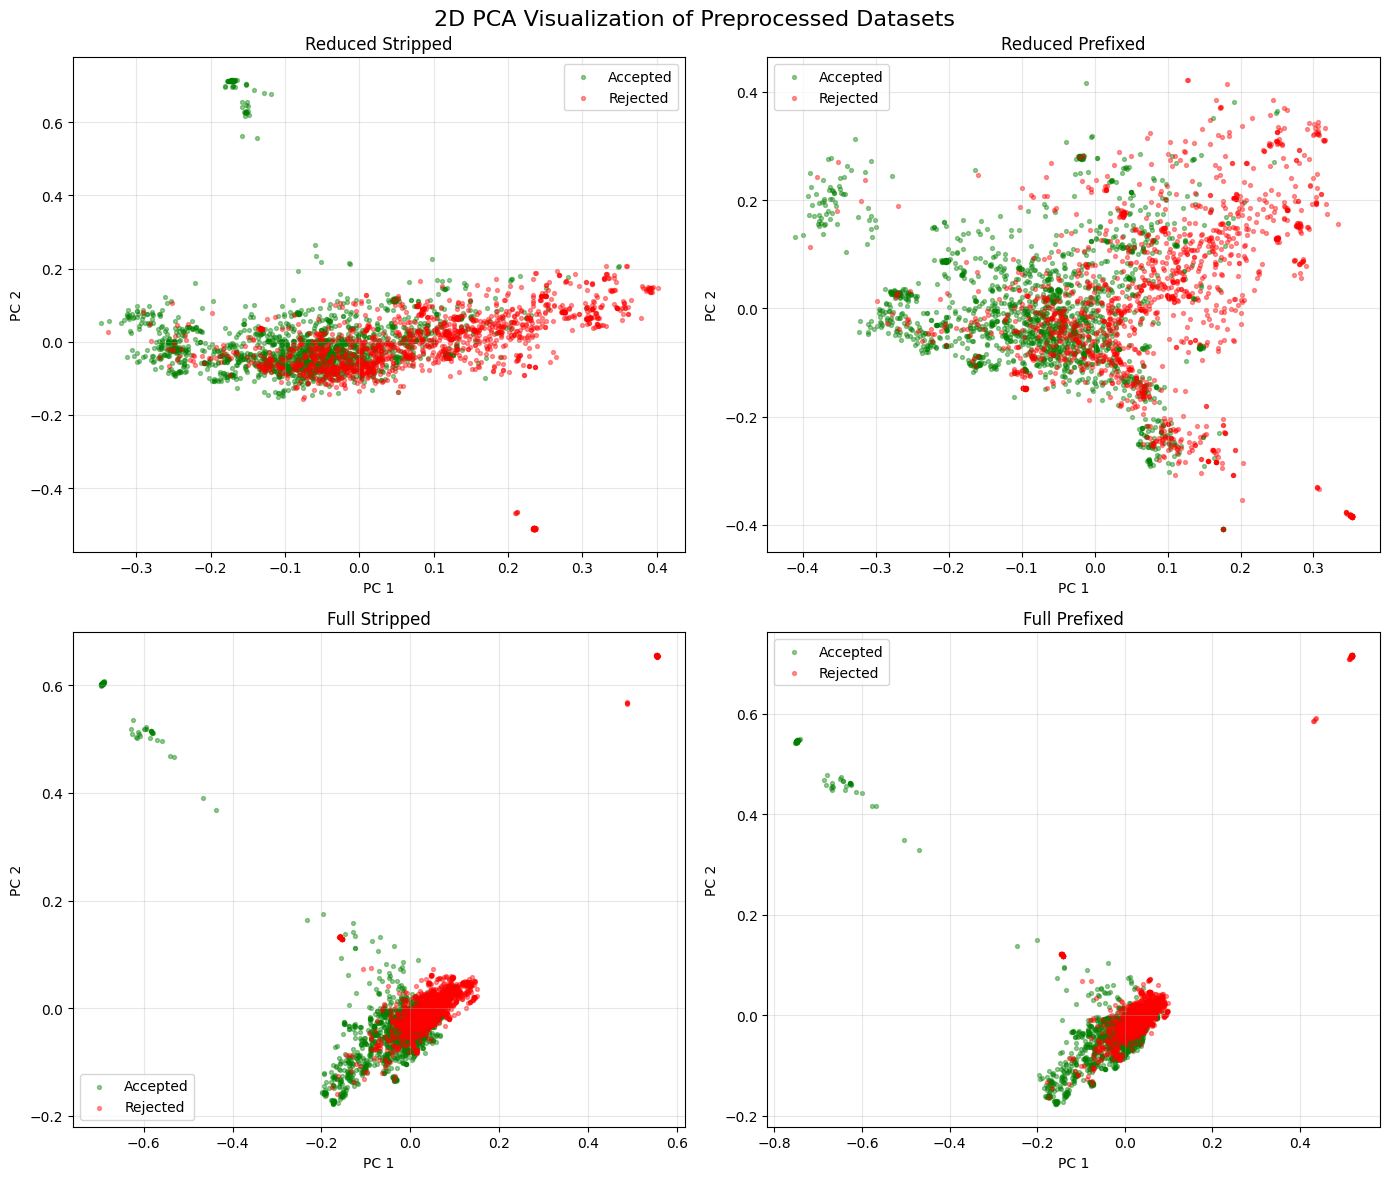

In [11]:
datasets = {
    "Reduced Stripped": X_lsa_reduced_stripped,
    "Reduced Prefixed": X_lsa_reduced_prefixed,
    "Full Stripped": X_lsa_full_stripped,
    "Full Prefixed": X_lsa_full_prefixed,
}
datasets_stripped = {
    "Reduced Stripped": X_lsa_reduced_stripped,
    "Full Stripped":    X_lsa_full_stripped,
}

labels = ads_texts_df['label'].values

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
os.makedirs('figures_and_tables', exist_ok=True)

for ax, (name, X_data) in zip(axes, datasets.items()):
    pca = PCA(n_components=2, random_state=8)
    X_pca = pca.fit_transform(X_data)
    
    scatter1 = ax.scatter(X_pca[labels == 1, 0], X_pca[labels == 1, 1],
                          c='green', alpha=0.4, s=8, label='Accepted')
    scatter2 = ax.scatter(X_pca[labels == 0, 0], X_pca[labels == 0, 1],
                          c='red', alpha=0.4, s=8, label='Rejected')
    
    ax.set_title(f'{name}')
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('2D PCA Visualization of Preprocessed Datasets', fontsize=16)
plt.savefig(os.path.join('figures_and_tables', "pca.png"))
plt.tight_layout()
plt.show()

# 5.Cuvamo podatke

In [12]:
output_dir = "preprocessed_data"
os.makedirs(output_dir, exist_ok=True)

np.save(os.path.join(output_dir, "labels.npy"), labels)

sparse.save_npz(os.path.join(output_dir, "X_stripped_count.npz"), X_stripped_count)
sparse.save_npz(os.path.join(output_dir, "X_prefixed_count.npz"), X_prefixed_count)

np.save(os.path.join(output_dir, "feature_names_count_stripped.npy"),
        count_vectorizer.get_feature_names_out())
np.save(os.path.join(output_dir, "feature_names_count_prefixed.npy"),
        count_vectorizer.get_feature_names_out())

stripped_df.to_pickle(os.path.join(output_dir, "stripped_df.pkl"))
prefixed_df.to_pickle(os.path.join(output_dir, "prefixed_df.pkl"))

tfidf_matrices = {
    "X_tfidf_reduced_stripped": X_tfidf_reduced_stripped,
    "X_tfidf_reduced_prefixed": X_tfidf_reduced_prefixed,
    "X_tfidf_full_stripped": X_tfidf_full_stripped,
    "X_tfidf_full_prefixed": X_tfidf_full_prefixed,
}
lsa_matrices = {
    "X_lsa_reduced_stripped": X_lsa_reduced_stripped,
    "X_lsa_reduced_prefixed": X_lsa_reduced_prefixed,
    "X_lsa_full_stripped": X_lsa_full_stripped,
    "X_lsa_full_prefixed": X_lsa_full_prefixed,
}

for name, mat in tfidf_matrices.items():
    sparse.save_npz(os.path.join(output_dir, f"{name}.npz"), mat)

for name, mat in lsa_matrices.items():
    np.save(os.path.join(output_dir, f"{name}.npy"), mat)

feature_names = {
    "feature_names_tfidf_reduced_stripped": feature_names_reduced_stripped,
    "feature_names_tfidf_reduced_prefixed": feature_names_reduced_prefixed,
    "feature_names_tfidf_full_stripped": feature_names_full_stripped,
    "feature_names_tfidf_full_prefixed": feature_names_full_prefixed,
}
with open(os.path.join(output_dir, "feature_names_tfidf.pkl"), "wb") as f:
    pickle.dump(feature_names, f)
